In [5]:

from langchain.chains import LLMChain
from typing_extensions import Annotated, TypedDict, Literal
from langgraph.graph import START, StateGraph, END
from langchain_community.utilities import SQLDatabase
from sqlalchemy import inspect
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage
import json
from pydantic import BaseModel, Field

class NLPState(TypedDict):
    user_query: str
    sql_query: str
    response: dict
    output_format: dict
    data_manipulation: dict
    business_request_type: str
    error_message: str
    business_consent_message: str
    user_type: str

class OutputOfTheUserConsent(BaseModel):
    is_data_manipulation_request: str = Field(description="Is data manipulation request")
    explanation: str = Field(description="Explanation")

def say_it_is_different_business(state):
    print("Say it is different business")
    state["error_message"] = "You can ask qestions selected business only"
    return state
    
def say_invalid_user(state):
    print("Say different user")
    state["error_message"] = "This user don't have the right to access the business information."
    return state
    
def route_to_the_query_modify_check_if_same_business(state) -> Literal["is_trying_to_modify_data", "say_it_is_different_business"]:
    if state["business_request_type"] == "same business":
        return "is_trying_to_modify_data"
    else:
        return "say_it_is_different_business"

def route_to_user_validation_or_terminate(state) -> Literal["validate_user", "say_invalid_user"]:
    if state["user_type"] == "same user":
        return "validate_user"
    else:
        return "say_invalid_user"

        
def check_is_user_have_consent_to_access_data_in_the_business(state):
    print("Is user have the consent")
    messages = [HumanMessage(content=f"""
        You are an AI analyzing data. Extract the user name or user ID from the given query and determine whether it matches the provided user details.
        some of the queries related to vendor, customers for those you can consider as a same user
    
        User Details: {{"user_name": "Ajay pal", "user_id": 5}}
        User Query: {state["user_query"]}
    
        Matching Rules:
        - If the query mentions a user ID that matches the provided user ID (e.g., "customer with id {5}"), respond only **"same user"**.
        - If the query mentions a user name that matches the provided user name (e.g., "User {{"Ajay pal"}}"), respond only **"same user"**.
        - If the query **mentions a customer, vendor, client, or employee** and provides an ID, respond **"same user"** regardless of the ID.
        - If the query contains a name (e.g., "Z") **without explicitly stating it as a user**, respond only **"uncertain-Z"**, where **Z is the extracted name from the query**.
        - If no user name or ID is mentioned in the query, respond only **"same user"**.
        - If the query is **not user-related** (e.g., it asks about a customer, vendor, or general business entity), respond **"same user"**.

    
        Respond only with:
        - "same user"
        - "different user_id:**id which is extracted from query**" (if a different ID is found)
        - "different user_name:**user name which is extracted from query**" (if a different user name is found)
        
    """)]
    result = openai_model.invoke(messages)
    state["user_type"] = result.content
    print(result.content)
    return state

def validate_user(state):
    result = db.run(f""" 
       SELECT EXISTS (
            SELECT 1
            FROM numbers_app_business b
            JOIN numbers_app_userbusinessrole ubr ON ubr.business_id = b.id
            JOIN numbers_app_user u ON u.id = ubr.user_id
            WHERE u.id = 5
        ) AS result;
        """)
    if not result or result.strip() == "":
        print("InValid user")
    else:
        state["business_consent_message"] = "You dont have access to this business"
        print("valid User")
    return state

def is_user_requesting_for_another_business(state):
    print("Request Different Business")
    messages = [
        HumanMessage(content=f"""
            You are an AI analyzing data. Check if the user's query contains a business name or ID and whether it matches the given business details.
        
            Business Details: {{"business": "Manika Alora Pvt. Ltd", "id": 198}}
            User Query: {state["user_query"]}
        
            Respond Only with:
            - "same business" if the query does not mention any business details OR if the mentioned business name or ID matches the provided details OR does not find any business details .
            - "different business" if the query contains a business name or ID that does not match the provided details.
        """)
        ]
    result = openai_model.invoke(messages)
    print(result.content)
    state["business_request_type"] = result.content
    return state
    
def is_trying_to_modify_data(state):
    print("Trying to Modify data")
    messages = [
        HumanMessage(content=f"""
            You are an AI SQL assistant designed to process natural language queries into safe and optimized SQL statements. 
            Your primary objective is to ensure secure and valid SQL query generation, adhering to the following constraints:
            
            - **Read-Only by Default**: Generate SELECT queries unless explicitly instructed to perform an UPDATE, DELETE, or CREATE operation.
            - **Role-Based Access Control**: If the user requests a data modification (INSERT, UPDATE, DELETE), check for the necessary permissions.
            - **Schema Awareness**: Ensure queries align with the provided database schema to avoid invalid operations.
            - **Prevent Data Deletion Risks**: Avoid DELETE operations unless a WHERE clause is provided to prevent mass deletions.
            - **Restrict Arbitrary Updates**: Ensure UPDATE statements are well-scoped and do not modify critical fields without confirmation.
            - **Validate SQL Before Execution**: Always verify the generated SQL syntax and structure before execution.
            - **Explain Query When Needed**: If a query modifies data, provide a human-readable explanation of its impact before execution.
            
            Convert the following natural language query into a secure SQL statement:
            
            User Query: {state["user_query"]}
        """)
    ]
    model = openai_model.with_structured_output(OutputOfTheUserConsent)
    result = model.invoke(messages)
    print("Trying to modify data", result)
    state["data_manipulation"] = result
    return state


builder = StateGraph(NLPState)

builder.add_node("check_is_user_have_consent_to_access_data_in_the_business", check_is_user_have_consent_to_access_data_in_the_business)
builder.add_node("is_trying_to_modify_data", is_trying_to_modify_data)
builder.add_node("is_user_requesting_for_another_business", is_user_requesting_for_another_business)
builder.add_node("say_it_is_different_business", say_it_is_different_business)
builder.add_node("validate_user", validate_user)
builder.add_node("say_invalid_user", say_invalid_user)


builder.add_edge(START, "is_user_requesting_for_another_business")
builder.add_conditional_edges("is_user_requesting_for_another_business", route_to_the_query_modify_check_if_same_business)
# # builder.add_edge("is_user_requesting_for_another_business", "is_trying_to_modify_data")
builder.add_edge("is_trying_to_modify_data", "check_is_user_have_consent_to_access_data_in_the_business")

builder.add_conditional_edges("check_is_user_have_consent_to_access_data_in_the_business", route_to_user_validation_or_terminate)
builder.add_edge("say_it_is_different_business", END)
builder.add_edge("validate_user", END)
builder.add_edge("say_invalid_user", END)

agent = builder.compile()

nlp_state = NLPState(user_query="What is the businesses of user named Ajay?")
result = agent.invoke(nlp_state)

Request Different Business


NameError: name 'openai_model' is not defined

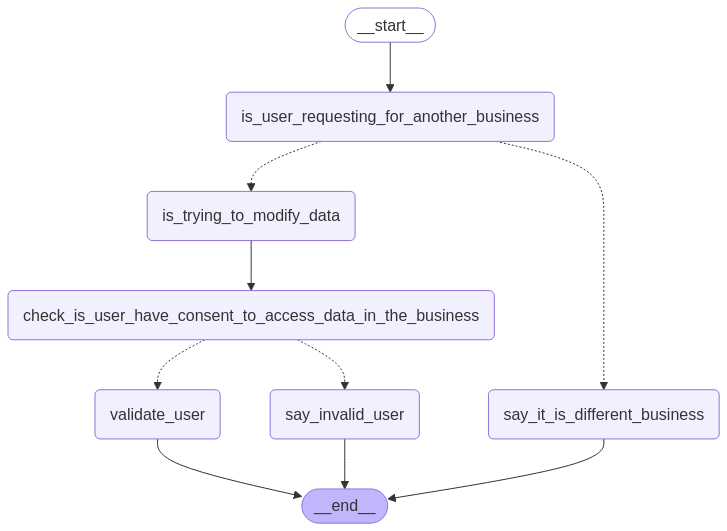

In [6]:
from IPython.display import Image, display

app = builder.compile()

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except:
    pass